# トレンドフォロー：銘柄を自分自身の過去と比べる

レシピ 02/01 は銘柄どうしを順位づけして、勝っているものを買いました。今回は銘柄どうしを
いっさい比べません。それぞれを自分自身の過去と比べて、その結果だけでロング、ショート、
あるいは何も持たないかを決めます。違いは小さく聞こえますが、できあがるポートフォリオは
まったく別物です。クロスセクショナル・モメンタムは作り方からしてほぼマーケットニュートラル
ですが、時系列モメンタムは見るすべての銘柄で方向を持ちます。ショートを取れることこそが、
この戦略が存在する理由です。

これはマネージドフューチャーズの中核にある考え方です。そして機能させているのはシグナル
ではありません。静かな銘柄と荒い銘柄が同じだけリスクを出すようにするボラティリティ・
スケーリングと、回転率の予算です。速いトレンドシグナルはよく売買しますし、その代金は
セクション04ですでに測りました。

## ここで使う用語

| 用語 | 意味 |
| --- | --- |
| 時系列モメンタム | 自分の過去より上がっている銘柄をロング、下がっている銘柄をショートすること |
| ボラティリティ・スケーリング | どの銘柄も同じくらいのリスクになるようにポジションの大きさを決めること |
| ボラティリティ目標 | ポートフォリオ全体で狙う年率ボラティリティ |
| 回転率（ターンオーバー） | 資産額に対して、どれだけ売買したかの割合 |
| クライシスアルファ | 相場が最悪の月にこそトレンドフォローは効く、という主張 |
| プラトー（平坦域） | 1点だけでなく、その周辺のパラメータでも同じように機能する範囲 |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, quant, sql_expr
import cookbook_utils as cu

LOOKBACK = 252
VOL_WINDOW = 60
TARGET_VOL = 0.10
COST_BPS = 10.0
# A numpy scalar inside a builder expression renders as a function call, so the
# annualization factor is kept as a plain Python float.
ANNUALIZE = float(np.sqrt(252))

## 1. ユニバース

大型株30銘柄です。CTA が売買する対象ではありません。実際の運用では、株価指数、金利、通貨、
商品の先物にまたがって同じことをします。ポジションが全部同じ賭けにならないようにするためです。
以下のコードはその種のデータでもそのまま動きます。分散だけはこのフィクスチャでは用意できない
ので、結果のセクションで、ごまかさずにそのことを数字で示します。

In [2]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01")
db = h5i_db.Database(cu.fresh_db("alpha_trend_following"), create=True)
prices = daily.sort_by([("ts", "ascending"), ("symbol", "ascending")])
db.create_table("prices", prices.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices", prices, note="30 large caps, 2018-2026")
db.snapshot("prices-v1", tables=["prices"], note="Everything here reads this cut")
print(f"{prices.num_rows:,} rows, {daily.to_pandas()['symbol'].nunique()} names")
daily.to_pandas().head(3)

64,020 rows, 30 names


,ts,symbol,open,high,low,close,adj_close,volume
0,2018-01-02 20:00:00+00:00,AAPL,42.540001,43.075001,42.314999,43.064999,40.267075,102223600
1,2018-01-02 20:00:00+00:00,NVDA,4.894500,4.987500,4.862500,4.983750,4.922529,355616000
2,2018-01-02 20:00:00+00:00,GE,84.251045,86.215950,84.011429,86.168022,80.953125,16185981


## 2. シグナルとリスクを1つのクエリで

銘柄ごと・日ごとに3つを計算します。日次リターン、ポジションの大きさを決める直近の
ボラティリティ、そしてトレンドシグナル本体です。ボラティリティは指数加重の標準偏差で、
同じ長さの単純な移動窓よりレジーム変化に速く反応します。

どれも過去しか見ていません。t 行が示すポジションを売買するのは t+1 で、そのずらしは
暗黙の前提に任せず、下のコードで明示的に行います。

In [3]:
previous = sql_expr("lag(adj_close)").over(partition_by="symbol", order_by="ts")
past = sql_expr(f"lag(adj_close, {LOOKBACK})").over(partition_by="symbol", order_by="ts")
features = (
    db.table("prices", snapshot="prices-v1")
    .with_columns(previous=previous, past=past)
    .with_columns(
        ret=col("adj_close") / col("previous") - 1,
        trend=col("adj_close") / col("past") - 1,
    )
    .filter(col("ret").is_not_null() & col("trend").is_not_null())
)
scaled = (
    features.with_columns(
        vol=col("ret").rolling_std(VOL_WINDOW, order_by="ts", partition_by="symbol")
    )
    .with_columns(annual_vol=col("vol") * ANNUALIZE)
    .select(
        ts=col("ts"),
        symbol=col("symbol"),
        ret=col("ret"),
        trend=col("trend"),
        annual_vol=col("annual_vol"),
    )
    .sort(["ts", "symbol"])
)
panel = scaled.to_pandas().dropna()
print(f"{len(panel):,} symbol-days with a signal and a volatility estimate")
panel.head(3).round(4)

56,430 symbol-days with a signal and a volatility estimate


/tmp/ipykernel_97633/2338477227.py:28: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  panel.head(3).round(4)


,ts,symbol,ret,trend,annual_vol
30,2019-01-04 20:00:00+00:00,AAPL,0.0427,-0.1263,1.5973
31,2019-01-04 20:00:00+00:00,ABBV,0.0322,-0.0741,0.7315
32,2019-01-04 20:00:00+00:00,AMZN,0.0501,0.3082,0.8453


## 3. ポジション

符号はシグナルが決め、大きさはボラティリティが決めます。各銘柄に `TARGET_VOL / n` の
リスクを割り当てるので、ボラティリティが2倍になった銘柄はポジションが半分になり、
出すリスクは以前と同じままです。

ウェイトには上限をかけます。上限がないと、値動きが静まった銘柄がポートフォリオより
大きなポジションを取ります。確信からではなく、ただの割り算の結果としてです。

In [4]:
signal = np.sign(panel["trend"])
names = panel.groupby("ts")["symbol"].transform("size")
panel["weight"] = (
    signal * (TARGET_VOL / np.sqrt(names)) / panel["annual_vol"]
).clip(-0.2, 0.2)

base = panel.pivot(index="ts", columns="symbol", values="weight").fillna(0.0)
returns = panel.pivot(index="ts", columns="symbol", values="ret").fillna(0.0)
unscaled = (base.shift(1).fillna(0.0) * returns).sum(axis=1)
print(f"realized volatility before the overlay: "
      f"{unscaled.std() * ANNUALIZE:.1%} against a {TARGET_VOL:.0%} target")

realized volatility before the overlay: 21.2% against a 10% target


各銘柄を `TARGET_VOL / sqrt(n)` で測るのは、銘柄どうしが独立だという前提です。実際には
独立ではありません。大型株30銘柄はいっしょに動くので、ポートフォリオ全体はまったく別の
水準に着地します。正しい定数を議論するかわりに、運用そのものの直近ボラティリティを測って
目標へスケールします。スケールの入力はすべてラグを取ってあるので、その日のポジションが
その日の結果を使うことはありません。

In [5]:
realized = unscaled.rolling(VOL_WINDOW).std() * ANNUALIZE
scale = (TARGET_VOL / realized).shift(1).clip(upper=3.0).fillna(0.0)
weights = base.mul(scale, axis=0)

held = weights.shift(1).fillna(0.0)  # decided yesterday, held today
gross = (held * returns).sum(axis=1)
turnover = (weights - weights.shift(1).fillna(0.0)).abs().sum(axis=1)
net = gross - turnover * COST_BPS / 10_000

print(f"realized volatility after   {gross.std() * ANNUALIZE:.1%}")
print(f"average gross exposure      {held.abs().sum(axis=1).mean():.2f}x")
print(f"average net exposure        {held.sum(axis=1).mean():+.2f}x")
print(f"average daily turnover      {turnover.mean():.3f} of book")
print(f"annual cost at {COST_BPS:.0f}bp         {turnover.mean() * 252 * COST_BPS / 10_000:.2%}")

realized volatility after   10.7%
average gross exposure      1.31x
average net exposure        +0.71x
average daily turnover      0.099 of book
annual cost at 10bp         2.50%


ネットエクスポージャーは、これがトレンドの運用なのか、姿を変えたロングなのかを判定する
数字です。ゼロの両側に相応の時間いるべきで、いちどもショートにならないなら、その戦略は
手間をかけただけのマーケットです。

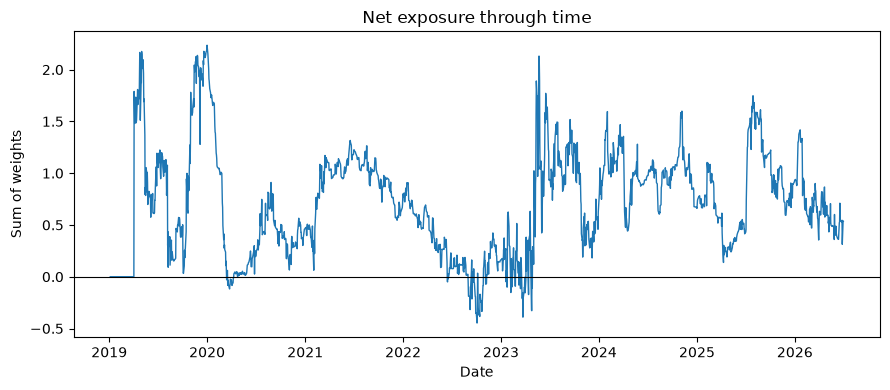

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(held.index, held.sum(axis=1), linewidth=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Net exposure through time")
ax.set_xlabel("Date")
ax.set_ylabel("Sum of weights")
fig.tight_layout()

## 4. 共通の道具でパフォーマンスを測る

リターン系列はテーブルとして保存し、`quant.perf` で分析します。レシピ 06/01 が使うのと
同じコードです。2つの戦略がそれぞれ別の実装からシャープレシオを報告したら、それは
2つの数字であって、比較ではありません。

In [7]:
returns_table = pa.Table.from_pandas(
    pd.DataFrame({"ts": net.index, "ret": net.to_numpy()}), preserve_index=False
)
db.create_table("trend_returns", returns_table.schema, time_column="ts")
db.append("trend_returns", returns_table, note=f"{LOOKBACK}-day trend, {TARGET_VOL:.0%} vol target")

benchmark_table = pa.Table.from_pandas(
    pd.DataFrame({"ts": returns.index, "ret": returns.mean(axis=1).to_numpy()}),
    preserve_index=False,
)
db.create_table("universe_returns", benchmark_table.schema, time_column="ts")
db.append("universe_returns", benchmark_table, note="equal-weight universe")
db.snapshot("returns-v1", tables=["trend_returns", "universe_returns"])

strategy = quant.returns(db, "trend_returns", snapshot="returns-v1")
universe = quant.returns(db, "universe_returns", snapshot="returns-v1")
comparison = pd.DataFrame(
    {"trend (net)": strategy.stats(benchmark=universe), "universe": universe.stats()}
)
comparison.round(4)

,trend (net),universe
n_periods,1881,1881
period_start,2019-01-04 20:00:00+00:00,2019-01-04 20:00:00+00:00
period_end,2026-06-30 20:00:00+00:00,2026-06-30 20:00:00+00:00
cumulative_return,0.415774,3.402795
annual_return,0.047681,0.219667
annual_volatility,0.107285,0.179429
sharpe_ratio,0.487915,1.197099
sortino_ratio,0.675794,1.720007
downside_risk,0.077458,0.12488
max_drawdown,-0.263335,-0.322724


リターンの行より先にボラティリティの行を読んでください。ボラティリティ目標の意味は、
出てくる数字が注文どおりの水準になることです。実現ボラティリティが `TARGET_VOL` から
遠ければ、サイジングが仕事をしていないので、そのリターンは別の戦略のリターンです。

この期間ではユニバースのほうが戦略より強く、それは想定どおりです。バグではありません。長い上昇
相場で、相関の高い大型株30銘柄にトレンドの運用をさせるのは、いちばん苦手なことをさせて
いるのと同じです。理由はセクション7で数字にします。

In [8]:
print(f"target volatility   {TARGET_VOL:.1%}")
print(f"realized volatility {strategy.stats()['annual_volatility']:.1%}")
print(f"beta to the universe {strategy.stats(benchmark=universe)['beta']:+.2f}")

target volatility   10.0%
realized volatility 10.7%
beta to the universe +0.21


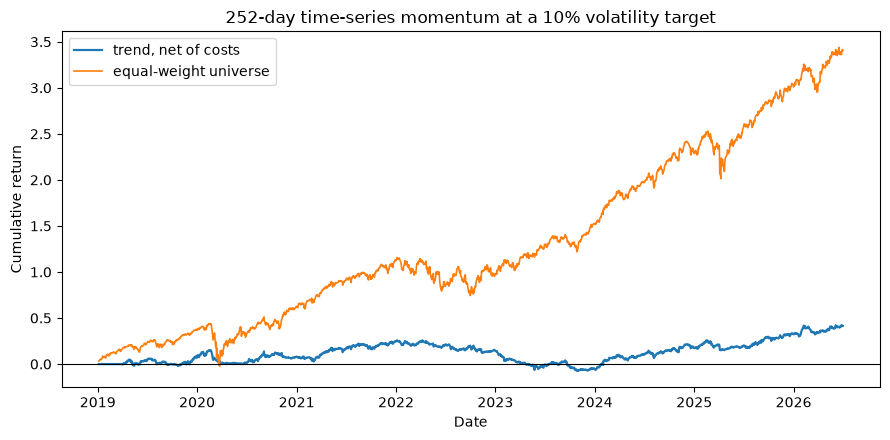

In [9]:
curve = strategy.equity_curve().to_pandas()
bench_curve = universe.equity_curve().to_pandas()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(curve["ts"], curve["cumulative_return"], linewidth=1.6, label="trend, net of costs")
ax.plot(bench_curve["ts"], bench_curve["cumulative_return"], linewidth=1.2, label="equal-weight universe")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"{LOOKBACK}-day time-series momentum at a {TARGET_VOL:.0%} volatility target")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.legend()
fig.tight_layout()

## 5. 試す価値のある主張：悪い日に何が起きるか

トレンドフォローが売り込まれる根拠は、平均リターンよりもドローダウン局面での振る舞いです。
検証できる形にすると主張は狭くなります。ユニバースにとって最悪の日に、この戦略のリターンは
ロングを持っていた場合より良いのか、という問いです。

In [10]:
joined = pd.DataFrame({"strategy": net, "universe": returns.mean(axis=1)}).dropna()
buckets = pd.qcut(joined["universe"], 5, labels=["worst", "poor", "flat", "good", "best"])
by_bucket = joined.groupby(buckets, observed=True).agg(
    days=("strategy", "size"),
    universe=("universe", "mean"),
    strategy=("strategy", "mean"),
)
by_bucket["difference"] = by_bucket["strategy"] - by_bucket["universe"]
by_bucket.round(5)

,days,universe,strategy,difference
universe,,,,
worst,377,-0.01310,-0.00492,0.00818
poor,376,-0.00263,-0.00179,0.00084
flat,376,0.00106,0.00088,-0.00018
good,376,0.00488,0.00297,-0.00192
best,376,0.01409,0.00392,-0.01017


日次データでの正直な答えはたいてい「和らげはするが、ヘッジにはならない」です。1日は
このシグナルが反応する時間軸よりずっと短いので、この種の運用が実際に提供する保護は、
下落が続いた数か月に現れます。単発の最悪の日ではありません。日次版をクライシスアルファ
として引用するのは、よくある言い過ぎです。

In [11]:
monthly = joined.resample("ME").apply(lambda column: (1 + column).prod() - 1)
worst_months = monthly.nsmallest(6, "universe")
print("the six worst months for the universe:")
print((worst_months * 100).round(2).to_string())
print(f"\nstrategy beat the universe in {int((worst_months['strategy'] > worst_months['universe']).sum())} of 6")

the six worst months for the universe:
                           strategy  universe
ts                                           
2020-03-31 00:00:00+00:00     -3.27    -10.38
2022-09-30 00:00:00+00:00      3.46     -8.78
2020-02-29 00:00:00+00:00     -4.36     -7.90
2022-06-30 00:00:00+00:00      1.49     -7.32
2022-04-30 00:00:00+00:00     -1.13     -6.34
2019-05-31 00:00:00+00:00     -4.22     -6.20

strategy beat the universe in 6 of 6


## 6. ルックバックは選択か、当てはめか

252日でだけ効いて他では効かないパラメータは、当てはめたパラメータです。隣り合う時間軸に
またがるプラトーは、手に入る中でいちばん弱い証拠ではありますが、持つ価値はあります。
レシピ 06/03 は同じ問いを確率にします。

In [12]:
def run_lookback(days: int) -> dict:
    lag = sql_expr(f"lag(adj_close, {days})").over(partition_by="symbol", order_by="ts")
    frame = (
        db.table("prices", snapshot="prices-v1")
        .with_columns(previous=previous, past=lag)
        .with_columns(
            ret=col("adj_close") / col("previous") - 1,
            trend=col("adj_close") / col("past") - 1,
        )
        .filter(col("ret").is_not_null() & col("trend").is_not_null())
        .with_columns(
            vol=col("ret").rolling_std(VOL_WINDOW, order_by="ts", partition_by="symbol")
        )
        .select(
            ts=col("ts"),
            symbol=col("symbol"),
            ret=col("ret"),
            trend=col("trend"),
            annual_vol=col("vol") * ANNUALIZE,
        )
        .sort(["ts", "symbol"])
        .to_pandas()
        .dropna()
    )
    count = frame.groupby("ts")["symbol"].transform("size")
    frame["weight"] = (
        np.sign(frame["trend"]) * (TARGET_VOL / np.sqrt(count)) / frame["annual_vol"]
    ).clip(-0.2, 0.2)
    b = frame.pivot(index="ts", columns="symbol", values="weight").fillna(0.0)
    r = frame.pivot(index="ts", columns="symbol", values="ret").fillna(0.0)
    raw = (b.shift(1).fillna(0.0) * r).sum(axis=1)
    overlay = (TARGET_VOL / (raw.rolling(VOL_WINDOW).std() * ANNUALIZE)).shift(1).clip(upper=3.0).fillna(0.0)
    w = b.mul(overlay, axis=0)
    turn = (w - w.shift(1).fillna(0.0)).abs().sum(axis=1)
    series = (w.shift(1).fillna(0.0) * r).sum(axis=1) - turn * COST_BPS / 10_000
    return {
        "lookback": days,
        "sharpe": float(series.mean() / series.std() * np.sqrt(252)),
        "annual turnover": float(turn.mean() * 252),
        "days": len(series),
    }


plateau = pd.DataFrame([run_lookback(days) for days in (63, 126, 189, 252, 315, 378)])
plateau.round(3)

,lookback,sharpe,annual turnover,days
0,63,-0.060,44.000,2070
1,126,0.044,32.606,2007
2,189,0.576,27.753,1944
3,252,0.488,25.021,1881
4,315,0.369,21.800,1818
5,378,0.535,19.490,1755


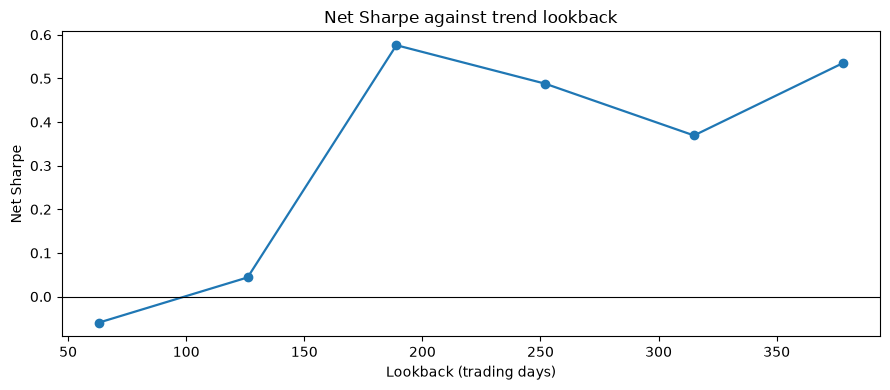

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(plateau["lookback"], plateau["sharpe"], marker="o", linewidth=1.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Net Sharpe against trend lookback")
ax.set_xlabel("Lookback (trading days)")
ax.set_ylabel("Net Sharpe")
fig.tight_layout()

## 7. このフィクスチャで示せないこと

大型株30銘柄は、30の顔をかぶった1つの賭けです。マネージドフューチャーズが評価されるのは、
金利、通貨、商品のトレンドを同時に持つからで、そこではポジション間の相関が十分に低く、
ボラティリティ目標が意味を持ちます。

下に出す平均ペア相関が、その事情を示す数字です。

In [14]:
correlation = returns.corr().to_numpy()
off_diagonal = correlation[~np.eye(len(correlation), dtype=bool)]
print(f"average pairwise correlation of the universe: {off_diagonal.mean():.2f}")
print(f"effective independent bets (1/(1+(n-1)r)) * n: "
      f"{len(correlation) / (1 + (len(correlation) - 1) * off_diagonal.mean()):.1f} "
      f"of {len(correlation)} names")

average pairwise correlation of the universe: 0.37
effective independent bets (1/(1+(n-1)r)) * n: 2.5 of 30 names


## まとめ

- 時系列モメンタムは銘柄を自分の過去と比べるので、方向を持ち、ショートにもなります。
  レシピ 02/01 との違いはそこに尽きます。
- ポジションを比較可能にするのはボラティリティ・スケーリングです。リターンを読む前に、
  実現ボラティリティが目標の近くに来ているかを確認してください。
- 回転率はコストであり、そのコストは脚注ではなくリターン系列に入れるべきものです。
  数字の出どころはレシピ 04/11 です。
- 「クライシスアルファ」は月次の主張であって日次の主張ではありません。日次の表がそれを
  はっきり示しています。
- ルックバックはピークよりプラトーで判断してください。
- 相関の高い株式だけのユニバースでは、この戦略にとっての分散の効果は示せません。
  フィクスチャが支えられないことは、そう書いてください。

In [15]:
db.close()